In [1]:
import pymc as pm
import numpy as np
import pytensor as pt
import pytensor.tensor as tt
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
s = []
for i in np.arange(347):
    s.append(str(i))

In [3]:
data = pd.read_csv('EVI.csv', header=0, names=s)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,337,338,339,340,341,342,343,344,345,346
0,0.4560,NaN,0.3975,0.3183,0.3022,0.2870,0.2886,0.2236,0.2318,0.1911,...,0.2832,0.3471,0.3432,NaN,0.3971,0.4401,0.3606,0.3702,0.4172,0.4218
1,0.4652,NaN,0.3807,0.3194,0.2936,0.2985,0.2810,0.2221,0.2281,0.1891,...,0.2933,0.3547,0.3450,NaN,0.4069,0.4418,0.3606,0.3621,NaN,0.4294
2,0.4642,NaN,0.3748,0.3107,0.2918,0.3008,0.2810,0.2221,0.2277,0.1851,...,0.2804,0.3445,0.3450,NaN,0.4032,0.4490,0.3527,0.3750,NaN,0.4099
3,0.4576,NaN,0.3624,0.3076,0.2811,0.3083,0.2754,0.2134,0.2194,0.1820,...,0.2998,0.3517,0.3450,NaN,0.4006,0.4494,0.3551,0.3586,NaN,0.4326
4,0.4468,NaN,0.3600,0.2974,0.2681,0.3129,0.2698,0.2099,0.2194,0.1773,...,0.2891,0.3464,0.3468,NaN,0.3861,0.4378,0.3388,0.3273,NaN,0.4228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,0.4263,NaN,0.3711,0.3008,0.2867,0.3200,0.2856,0.2336,0.2417,0.2061,...,0.3174,0.4838,0.2843,NaN,0.3790,0.4730,0.4753,0.3612,0.4667,0.4319
11296,0.4412,NaN,0.3804,0.3055,0.3123,0.2833,0.2856,0.2278,0.2267,0.1967,...,0.2627,0.2769,0.1956,NaN,0.1590,0.3577,0.3272,0.6130,0.8339,0.6045
11297,0.4610,NaN,0.3835,0.3165,0.3134,0.2578,0.2923,0.2326,0.2267,0.1927,...,0.1562,0.1554,0.1581,NaN,0.1512,0.1602,0.3670,0.6244,0.8663,0.7845
11298,0.4566,NaN,0.3876,0.3174,0.3208,0.2883,0.2869,0.2288,0.2263,0.1930,...,0.1645,0.1945,0.1680,NaN,0.2586,NaN,0.3687,0.5850,0.5896,0.7060


In [5]:
def inpaint_nans(data):
    """
    Inpaint NaNs in a DataFrame using linear interpolation.
    """
    return data.interpolate(method='linear', limit_direction='both', axis=0)

In [6]:
testSeries = data.iloc[0]

In [7]:
testSeries = inpaint_nans(testSeries)

ploteo datos de verdad

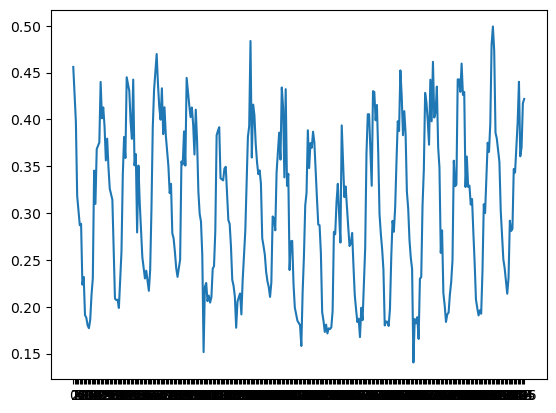

In [8]:
plt.plot(testSeries)

"Legacy"

In [ ]:
''' 
#%% Model definition
basic_model = pm.Model()
samplesPerYear = 23 #Number of datapoints per year
sigma_err_prior = 1/0.05 #Estimate of EVI error variance
dummyData = np.zeros([0])
shared_data = T.shared(dummyData, borrow=True) #Sahred data definition - Theano

#%% Model definition
with basic_model:
        ## prior for 15-day EVI, U(0-1)
        x = pm.Uniform("x", 0, 1, shape=samplesPerYear)
        x = Tensor.cast(x, 'float64') #required for theano
        
        ## prior for observation process, Exp(sigma_err_prior)
        sigma_err = pm.Exponential("sigma_err", sigma_err_prior)

        @T.compile.ops.as_op(itypes=[Tensor.dvector],otypes=[Tensor.dvector]) #original
        def loredo(x = x, profile=True):
            L = shared_data.get_value(borrow=True).shape[0]
            out = np.zeros(L)
            k = 0
            while True:
                if (k+1)*samplesPerYear < L:
                    out[k*samplesPerYear:(k+1)*samplesPerYear] = x[0:samplesPerYear]
                    k = k+1
                else:
                    diff = (k+1)*samplesPerYear - L
                    out[k*samplesPerYear:(k+1)*samplesPerYear-diff] = x[0:samplesPerYear-diff]
                    break
            return out  
        loredo.grad = lambda *y: y[0]  # Here's the klutz, llama al grad pero es un bug
        loredo.shape = shared_data.get_value(borrow=True).shape[0]    
               
        ## likelihood
        observation = pm.Normal("obs", mu=loredo(x), tau=1/sigma_err, observed=shared_data)
'''

Version 2025

In [10]:
def loredo_det(x, t, samplesPerYear):
    """
    A deterministic function that fills in a time series with the Loredo approach.
    Parameters:
    x: array-like, the input random variables vector.
    t: int, the total length of the output time series.
    samplesPerYear: int, the number of samples per year.
    Returns:
    out: array-like, the output time series of length t.
    """
    L = t
    out = np.zeros(L)
    k = 0
    while True:
        if (k+1)*samplesPerYear < L:
            out[k*samplesPerYear:(k+1)*samplesPerYear] = x[0:samplesPerYear]
            k = k+1
        else:
            diff = (k+1)*samplesPerYear - L
            out[k*samplesPerYear:(k+1)*samplesPerYear-diff] = x[0:samplesPerYear-diff]
            break         
    return out  

testing loredo_det

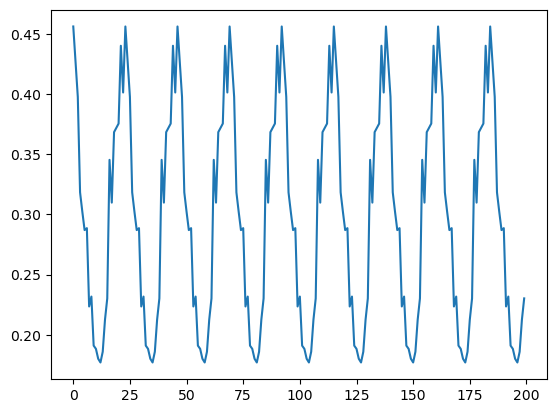

In [11]:
t = 200
x = testSeries[:23]
samplesPerYear = 23
aux = loredo_det(x, t, samplesPerYear)
plt.plot(aux)

defino datos de entrenamiento

In [12]:
trainData = testSeries[:100]
t = len(trainData)

In [14]:
data.shape[0]

11300

In [19]:
dataSubset = data.iloc[:10, :]

In [24]:
dataSubset.shape

(10, 347)

In [25]:
coords = {'timeSeriesTrainlength': np.arange(dataSubset.shape[1]),
          'pixels': np.arange(dataSubset.shape[0]),
          'samplesPerYear': 23}

In [26]:
coords

{'timeSeriesTrainlength': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172

In [23]:
pixelID = coords['pixels']

version normales correlacionadas

In [ ]:
#%% Model definition
sigma_err = 0.05

with pm.Model(coords=coords) as HierarchichalModel:
        
        '''
         floor_idx = pm.MutableData("floor_idx", floor_measure, dims="obs_id")
        county_idx = pm.MutableData("county_idx", county, dims="obs_id")

        # Priors
        mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0)
        sigma_a = pm.Exponential("sigma_a", 1)

        mu_b = pm.Normal("mu_b", mu=0.0, sigma=10.0)
        sigma_b = pm.Exponential("sigma_b", 1)

        # Random intercepts
        alpha = pm.Normal("alpha", mu=mu_a, sigma=sigma_a, dims="county")
        # Random slopes
        beta = pm.Normal("beta", mu=mu_b, sigma=sigma_b, dims="county")

        # Model error
        sigma_y = pm.Exponential("sigma_y", 1)

        # Expected value
        y_hat = alpha[county_idx] + beta[county_idx] * floor_idx

        # Data likelihood
        y_like = pm.Normal("y_like", mu=y_hat, sigma=sigma_y, observed=log_radon, dims="obs_id")
            '''

        L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
        cov = pm.Deterministic('cov', L.dot(L.T))

        mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0, dims=("samplesPerYear"))
        sigma_a = pm.Exponential("sigma_a", 1, dims=("samplesPerYear"))
    
        mus = pm.Normal('mus', mu=mu_a, sigma=sigma_a, dims=("samplesPerYear"))
        x = pm.MvNormal("x", mu=mus, cov=cov)
        # y = pm.Uniform("y", 0, 1, shape=0)
        y = []
        # print(x[0:4].eval())
        # print(samplesPerYear)

        ciclos = (t) // (samplesPerYear)
        resto = (t) % (samplesPerYear)

        # print(ciclos)
        # print(resto)

        for i in range(ciclos):
            # y = pm.math.concatenate([y, x], axis=0) 
            y = pm.math.concatenate([y, x], axis=0) 
        
        y = pm.math.concatenate([y, x[0:resto]], axis=0)
        # print(x.shape.eval())
        obs = pm.Normal("obs", mu=y, sigma=sigma_err, observed=dataSubset)

In [43]:
with model:
    pm.sample_prior_predictive()

Sampling: [mus, obs, packed_L, x]


In [44]:
with model:
    trace = pm.sample(target_accept=0.9)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [packed_L, mus, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 275 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 1191 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


Evaluo como da la posterior de la matriz de covarianza (que se supone que es la posta de este modelo) 

In [45]:
cov_trace = trace.posterior.cov.stack(dim=['chain', 'draw']).values

In [46]:
cov_trace_mean = cov_trace.mean(axis=2)

In [47]:
import plotly.express as px

fig = px.imshow(cov_trace_mean)
fig.show()

No parece haber grandes valores fuera de la diagonal

Prediccion

In [48]:
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["obs"])

Sampling: [obs]


<ErrorbarContainer object of 3 artists>

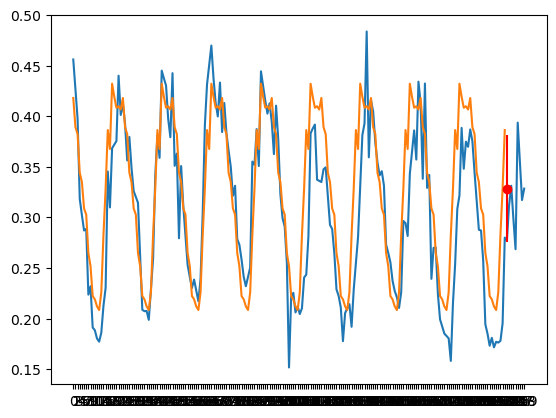

In [49]:
fecha_est = (t+1) % (samplesPerYear)
est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
est = est_[fecha_est,:]

plt.plot(testSeries[:210])
# plt.plot(reco)

reco_ = loredo_det(x_mean, t+1, samplesPerYear)
plt.plot(reco_)

plt.errorbar(x=t+1, y=est.mean(), yerr=est.std(), fmt='o', color='red')

Definicion de la clase para predecir

In [61]:
class LoredoModel:
    def __init__(self, trainData, samples_per_year=23, sigma_err=0.05):
        self.trainData = trainData
        self.samples_per_year = samples_per_year
        self.sigma_err = sigma_err
        self.model = None
        self.trace = None

    def trainUniform(self):
        with pm.Model() as model:
            x = pm.Uniform("x", 0, 1, shape=self.samples_per_year)
            y = []

            ciclos = (len(self.trainData)) // (self.samples_per_year)
            resto = (len(self.trainData)) % (self.samples_per_year)

            for i in range(ciclos):
                y = pm.math.concatenate([y, x], axis=0) 

            y = pm.math.concatenate([y, x[0:resto]], axis=0)
            obs = pm.Normal("obs", mu=y, sigma=self.sigma_err, observed=self.trainData)

            self.model = model

    def trainCorrelatedNormal(self):
        with pm.Model() as model:
            cov = np.eye(samplesPerYear)

            L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
            cov = pm.Deterministic('cov', L.dot(L.T))

            mus = pm.Normal('mus', mu=0.3, sigma=0.1, shape=samplesPerYear)
            x = pm.MvNormal("x", mu=mus, cov=cov)
            
            y = []

            ciclos = (t) // (samplesPerYear)
            resto = (t) % (samplesPerYear)

            for i in range(ciclos):
                y = pm.math.concatenate([y, x], axis=0) 
            
            y = pm.math.concatenate([y, x[0:resto]], axis=0)
            obs = pm.Normal("obs", mu=y, sigma=sigma_err, observed=trainData)
            self.model = model

    def sample(self):
        with self.model:
            self.trace = pm.sample(target_accept=0.9)

    def plot_trace(self):
        pm.traceplot(self.trace)
        plt.show()

    def posterior_predictive(self):
        with self.model:
            ppc = pm.sample_posterior_predictive(self.trace, var_names=["obs"])
        return ppc
    
    def estimation(self, ppc):
        fecha_est = (len(self.trainData) + 1) % (self.samples_per_year)
        est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
        est = est_[fecha_est, :]
        return est
    
    def plot_posterior_predictive(self, ppc):
        fecha_est = (len(self.trainData) + 1) % (self.samples_per_year)
        est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
        est = est_[fecha_est, :]
        plt.plot(self.trainData)
        reco_ = loredo_det(self.trace.posterior.x.mean(dim='chain').values, len(self.trainData) + 1, self.samples_per_year)
        plt.plot(reco_)
        plt.errorbar(x=len(self.trainData) + 1, y=est.mean(), yerr=est.std(), fmt='o', color='red')
        plt.show()

    def run(self):
        self.trainUniform()
        self.sample()
        ppc = self.posterior_predictive()
        est = self.estimation(ppc)
        return est
        # self.plot_posterior_predictive(ppc)
        # self.plot_trace()


In [62]:
# Example usage
loredo_model = LoredoModel(testSeries[:200])
est = loredo_model.run()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [obs]


(array([  10.,   41.,  211.,  656., 1057., 1114.,  628.,  237.,   38.,
           8.]),
 array([0.13131561, 0.17062863, 0.20994165, 0.24925467, 0.28856769,
        0.32788071, 0.36719373, 0.40650675, 0.44581977, 0.4851328 ,
        0.52444582]),
 <BarContainer object of 10 artists>)

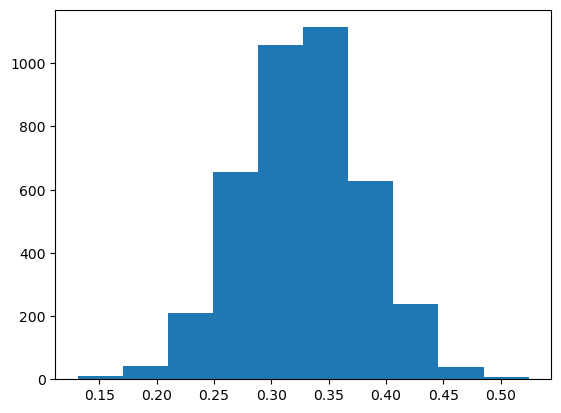

In [64]:
plt.hist(est)